In [1]:
!pip -q install kaggle opencv-python scikit-learn scikit-image matplotlib

In [2]:
from google.colab import files
import json
import os
import stat

print("📤 Upload your kaggle.json file")

uploaded = files.upload()

# Read kaggle.json
with open('kaggle.json', 'r') as f:
    kaggle_config = json.load(f)

# Create kaggle folder
os.makedirs('/root/.kaggle', exist_ok=True)

# Save kaggle.json in correct location
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_config, f)

# Set permissions
os.chmod('/root/.kaggle/kaggle.json', stat.S_IRUSR | stat.S_IWUSR)

print("✅ Kaggle API configured successfully!")

📤 Upload your kaggle.json file


Saving kaggle.json to kaggle.json
✅ Kaggle API configured successfully!


In [3]:
!kaggle datasets download -d alessiocorrado99/animals10 -p /content

# Unzip dataset
!unzip -q /content/animals10.zip -d /content/

print("✅ Dataset Downloaded and Extracted!")

Dataset URL: https://www.kaggle.com/datasets/alessiocorrado99/animals10
License(s): GPL-2.0
100% 586M/586M [00:05<00:00, 112MB/s]

✅ Dataset Downloaded and Extracted!


In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay

In [9]:

import os
from pathlib import Path

possible_paths = [
    "/content/raw-img",
    "/content/Animals-10/raw-img",
    "/content/animals10/raw-img",
    "/content/data/raw-img"
]

DATASET_PATH = None

for path in possible_paths:
    if os.path.exists(path):
        DATASET_PATH = Path(path)
        break

if DATASET_PATH is None:
    raise Exception("❌ Dataset folder not found!")

print("✅ Dataset Path Found:", DATASET_PATH)

print("\n📂 Available Classes:\n")
print(os.listdir(DATASET_PATH))

✅ Dataset Path Found: /content/raw-img

📂 Available Classes:

['mucca', 'ragno', 'scoiattolo', 'cavallo', 'elefante', 'gallina', 'cane', 'gatto', 'pecora', 'farfalla']


In [14]:
import os

print(os.listdir("/content/raw-img"))

['mucca', 'ragno', 'scoiattolo', 'cavallo', 'elefante', 'gallina', 'cane', 'gatto', 'pecora', 'farfalla']


In [17]:
import os

folders = os.listdir("/content/raw-img")

print("Available folders:\n")

for f in folders:
    print(f)

Available folders:

mucca
ragno
scoiattolo
cavallo
elefante
gallina
cane
gatto
pecora
farfalla


In [28]:
classes = [
    "cane",        # dog
    "gatto",       # cat
    "elefante",    # elephant
    "farfalla",    # butterfly
    "cavallo",     # horse
    "pecora"       # sheep
]

In [29]:
data = []
labels = []

IMAGE_SIZE = 100

for label, animal in enumerate(classes):

    folder = DATASET_PATH / animal

    print(f"📥 Loading images for : {animal}")

    for image_name in os.listdir(folder):

        try:

            image_path = folder / image_name

            # Read Image
            img = cv2.imread(str(image_path))

            # Resize Image
            img = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE))

            # Convert to Grayscale
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

            # Flatten Image
            img = img.flatten()

            # Store Data
            data.append(img)

            # Store Label
            labels.append(label)

        except:
            pass

# Convert list to numpy array
data = np.array(data)
labels = np.array(labels)

print("✅ Total Images Loaded :", len(data))

📥 Loading images for : cane
📥 Loading images for : gatto
📥 Loading images for : elefante
📥 Loading images for : farfalla
📥 Loading images for : cavallo
📥 Loading images for : pecora
✅ Total Images Loaded : 14532


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    data,
    labels,
    test_size=0.25,
    random_state=42
)

print("✅ Data Split Completed!")

✅ Data Split Completed!


In [31]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=3)

model.fit(X_train, y_train)

print("✅ KNN Model Trained Successfully!")


✅ KNN Model Trained Successfully!


In [32]:
predictions = model.predict(X_test)

In [33]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("🎯 Model Accuracy :", accuracy)


🎯 Model Accuracy : 0.37021745114230664


In [34]:
from sklearn.metrics import classification_report

print("\n📊 Classification Report:\n")

print(classification_report(
    y_test,
    predictions,
    target_names=classes
))



📊 Classification Report:

              precision    recall  f1-score   support

        cane       0.39      0.64      0.49      1221
       gatto       0.21      0.20      0.20       419
    elefante       0.23      0.19      0.21       358
    farfalla       0.36      0.34      0.35       569
     cavallo       0.60      0.16      0.26       634
      pecora       0.44      0.25      0.32       432

    accuracy                           0.37      3633
   macro avg       0.37      0.30      0.31      3633
weighted avg       0.39      0.37      0.35      3633



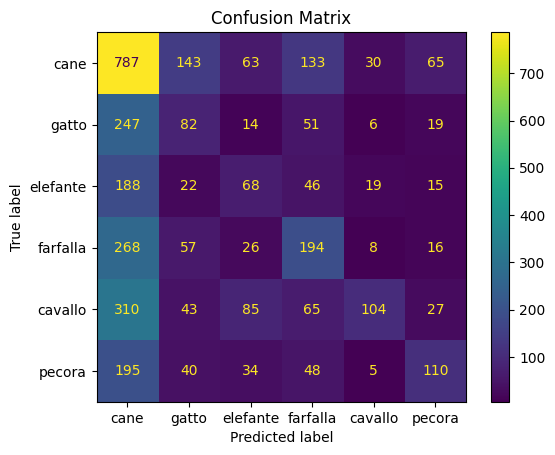

In [35]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    display_labels=classes
)

plt.title("Confusion Matrix")
plt.show()


In [36]:
from google.colab import files
import cv2
import numpy as np

print("📤 Upload a test image")

uploaded = files.upload()

# Get uploaded image path
test_image_path = list(uploaded.keys())[0]

# Read image
test_img = cv2.imread(test_image_path)

# Resize image
test_img = cv2.resize(test_img, (100, 100))

# Convert to grayscale
test_img = cv2.cvtColor(test_img, cv2.COLOR_BGR2GRAY)

# Flatten image
test_img = test_img.flatten().reshape(1, -1)

# Predict animal
prediction = model.predict(test_img)

# Output
print("🟢 Detected Animal :", classes[prediction[0]])

📤 Upload a test image


Saving butterfly.jpg to butterfly (1).jpg
🟢 Detected Animal : farfalla


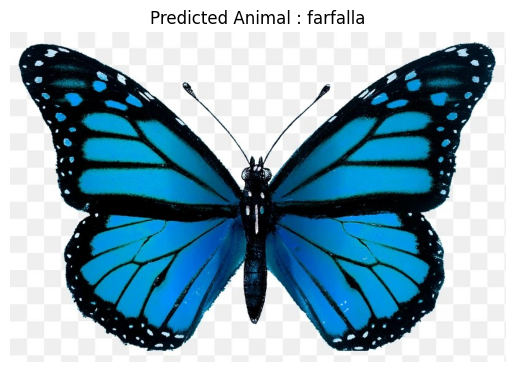

In [37]:
img_display = cv2.imread(test_image_path)
img_display = cv2.cvtColor(img_display, cv2.COLOR_BGR2RGB)

plt.imshow(img_display)
plt.title(f"Predicted Animal : {classes[prediction[0]]}")
plt.axis("off")
plt.show()